#📌 Extracción

In [1]:
import requests
import pandas as pd

# Extracción desde la API
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
raw_data = response.json()

# Conversión a DataFrame (normaliza la estructura anidada)
df = pd.json_normalize(raw_data, sep='_')

print(f'Shape: {df.shape}')
df.head()

Shape: (7267, 21)


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [2]:
# Exploración básica del dataset

# Dimensiones
print('=== DIMENSIONES ===')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')

# Columnas y tipos de datos
print('\n=== COLUMNAS Y TIPOS DE DATOS ===')
print(df.dtypes)

# Primeras filas
print('\n=== PRIMERAS 5 FILAS ===')
df.head()
# Valores nulos y únicos por columna
print('=== VALORES NULOS Y ÚNICOS ===')
resumen = pd.DataFrame({
    'tipo'      : df.dtypes,
    'nulos'     : df.isnull().sum(),
    'unicos'    : df.nunique(),
    'ejemplo'   : df.iloc[0]
})
print(resumen)
# Estadísticas descriptivas de columnas numéricas
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe()

=== DIMENSIONES ===
Filas: 7267 | Columnas: 21

=== COLUMNAS Y TIPOS DE DATOS ===
customerID                    object
Churn                         object
customer_gender               object
customer_SeniorCitizen         int64
customer_Partner              object
customer_Dependents           object
customer_tenure                int64
phone_PhoneService            object
phone_MultipleLines           object
internet_InternetService      object
internet_OnlineSecurity       object
internet_OnlineBackup         object
internet_DeviceProtection     object
internet_TechSupport          object
internet_StreamingTV          object
internet_StreamingMovies      object
account_Contract              object
account_PaperlessBilling      object
account_PaymentMethod         object
account_Charges_Monthly      float64
account_Charges_Total         object
dtype: object

=== PRIMERAS 5 FILAS ===
=== VALORES NULOS Y ÚNICOS ===
                              tipo  nulos  unicos       ejemplo
custom

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [3]:
# 1. VALORES NULOS
print('=== VALORES NULOS ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Sin valores nulos')
# 2. DUPLICADOS
print('=== DUPLICADOS ===')
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'customerID duplicados: {df["customerID"].duplicated().sum()}')
# 3. FORMATO — total_charges puede venir como string con espacios
print('=== VERIFICACIÓN DE TIPOS ===')
print(f'Tipo de account_Charges_Total: {df["account_Charges_Total"].dtype}')
print(f'Valores no numéricos en Total Charges:')
print(df[pd.to_numeric(df['account_Charges_Total'], errors='coerce').isnull()][['customerID','account_Charges_Total']])
# 4. INCONSISTENCIAS EN CATEGORÍAS
print('=== VALORES ÚNICOS POR COLUMNA CATEGÓRICA ===')
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'\n{col}: {df[col].unique()}')
# 5. RESUMEN GENERAL DE CALIDAD
print('=== RESUMEN DE CALIDAD ===')
calidad = pd.DataFrame({
    'nulos'      : df.isnull().sum(),
    'pct_nulos'  : (df.isnull().sum() / len(df) * 100).round(2),
    'duplicados' : df.duplicated(subset=[col]).sum() if False else '-',
    'tipo'       : df.dtypes,
    'unicos'     : df.nunique()
})
print(calidad[calidad['nulos'] > 0] if df.isnull().sum().sum() > 0 else calidad)

=== VALORES NULOS ===
Sin valores nulos
=== DUPLICADOS ===
Filas duplicadas: 0
customerID duplicados: 0
=== VERIFICACIÓN DE TIPOS ===
Tipo de account_Charges_Total: object
Valores no numéricos en Total Charges:
      customerID account_Charges_Total
975   1371-DWPAZ                      
1775  2520-SGTTA                      
1955  2775-SEFEE                      
2075  2923-ARZLG                      
2232  3115-CZMZD                      
2308  3213-VVOLG                      
2930  4075-WKNIU                      
3134  4367-NUYAO                      
3203  4472-LVYGI                      
4169  5709-LVOEQ                      
5599  7644-OMVMY                      
=== VALORES ÚNICOS POR COLUMNA CATEGÓRICA ===

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Churn: ['No' 'Yes' '']

customer_gender: ['Female' 'Male']

customer_Partner: ['Yes' 'No']

customer_Dependents: ['Yes' 'No']

phone_PhoneService: ['Yes' 'No']

phone_MultipleL

In [4]:
# 1. CORREGIR TIPO DE account_Charges_Total (string → float)
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

print('✅ account_Charges_Total convertido a float')
print(f'   Nulos generados: {df["account_Charges_Total"].isnull().sum()}')
# 2. IMPUTAR NULOS EN account_Charges_Total
# Clientes con tenure=0 no tienen cobros acumulados → se imputa con 0
df['account_Charges_Total'].fillna(0, inplace=True)

print('✅ Nulos imputados con 0')
print(f'   Nulos restantes: {df["account_Charges_Total"].isnull().sum()}')
# 3. CONVERTIR Churn a binario
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('✅ Churn convertido a binario')
print(df['Churn'].value_counts())
# 4. UNIFICAR CATEGORÍAS INCONSISTENTES
# "No internet service" y "No phone service" → "No"
cols_inconsistentes = [
    'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection',
    'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies',
    'phone_MultipleLines'
]

for col in cols_inconsistentes:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

print('✅ Categorías inconsistentes unificadas')
# 5. VERIFICACIÓN FINAL
print('=== VERIFICACIÓN FINAL ===')
print(f'Nulos totales:    {df.isnull().sum().sum()}')
print(f'Duplicados:       {df.duplicated().sum()}')
print(f'Shape:            {df.shape}')
df.dtypes

✅ account_Charges_Total convertido a float
   Nulos generados: 11
✅ Nulos imputados con 0
   Nulos restantes: 0
✅ Churn convertido a binario
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64
✅ Categorías inconsistentes unificadas
=== VERIFICACIÓN FINAL ===
Nulos totales:    224
Duplicados:       0
Shape:            (7267, 21)


/tmp/ipykernel_311/1917031660.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['account_Charges_Total'].fillna(0, inplace=True)


,0
customerID,object
Churn,float64
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object


#📊 Carga y análisis

In [5]:
# 1. ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS
print('=== VARIABLES NUMÉRICAS ===')
df.describe().round(2)
# 2. ESTADÍSTICAS DESCRIPTIVAS — VARIABLES CATEGÓRICAS
print('=== VARIABLES CATEGÓRICAS ===')
df.describe(include='object').T
# 3. MÉTRICAS ESPECÍFICAS DE VARIABLES CLAVE
numericas = ['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total']

for col in numericas:
    print(f'\n📊 {col}')
    print(f'   Media:             {df[col].mean():.2f}')
    print(f'   Mediana:           {df[col].median():.2f}')
    print(f'   Desv. estándar:    {df[col].std():.2f}')
    print(f'   Mínimo:            {df[col].min():.2f}')
    print(f'   Máximo:            {df[col].max():.2f}')
    print(f'   Q1 (25%):          {df[col].quantile(0.25):.2f}')
    print(f'   Q3 (75%):          {df[col].quantile(0.75):.2f}')
    print(f'   IQR:               {df[col].quantile(0.75) - df[col].quantile(0.25):.2f}')
# 4. TASA DE CHURN GENERAL
total = len(df)
churned = df['Churn'].sum()
print(f'\n🎯 TASA DE CHURN')
print(f'   Clientes totales:   {total:,}')
print(f'   Cancelaron:         {churned:,} ({churned/total*100:.2f}%)')
print(f'   Retenidos:          {total - churned:,} ({(total-churned)/total*100:.2f}%)')
# 5. COMPARACIÓN DE MÉTRICAS ENTRE CHURNED VS RETENIDOS
print('\n=== MÉTRICAS PROMEDIO: CHURN vs RETENIDOS ===')
comparacion = df.groupby('Churn')[numericas].mean().round(2)
comparacion.index = ['Retenidos', 'Evasión']
print(comparacion)

=== VARIABLES NUMÉRICAS ===
=== VARIABLES CATEGÓRICAS ===

📊 customer_tenure
   Media:             32.35
   Mediana:           29.00
   Desv. estándar:    24.57
   Mínimo:            0.00
   Máximo:            72.00
   Q1 (25%):          9.00
   Q3 (75%):          55.00
   IQR:               46.00

📊 account_Charges_Monthly
   Media:             64.72
   Mediana:           70.30
   Desv. estándar:    30.13
   Mínimo:            18.25
   Máximo:            118.75
   Q1 (25%):          35.42
   Q3 (75%):          89.88
   IQR:               54.45

📊 account_Charges_Total
   Media:             2277.18
   Mediana:           1389.20
   Desv. estándar:    2268.65
   Mínimo:            0.00
   Máximo:            8684.80
   Q1 (25%):          396.20
   Q3 (75%):          3778.52
   IQR:               3382.32

🎯 TASA DE CHURN
   Clientes totales:   7,267
   Cancelaron:         1,869.0 (25.72%)
   Retenidos:          5,398.0 (74.28%)

=== MÉTRICAS PROMEDIO: CHURN vs RETENIDOS ===
           cust

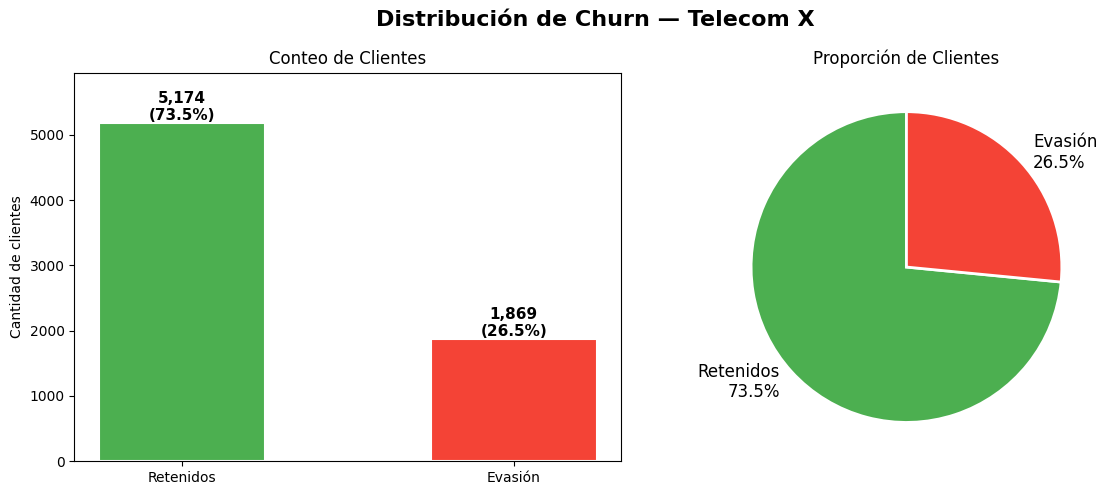

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# DATOS
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
labels       = ['Retenidos', 'Evasión']
colors       = ['#4CAF50', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución de Churn — Telecom X', fontsize=16, fontweight='bold')

# --- GRÁFICO DE BARRAS ---
bars = axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Conteo de Clientes')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].set_ylim(0, churn_counts.max() * 1.15)
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=11)

# --- GRÁFICO DE TORTA ---
axes[1].pie(
    churn_pct.values,
    labels=[f'{l}\n{p:.1f}%' for l, p in zip(labels, churn_pct.values)],
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
axes[1].set_title('Proporción de Clientes')

plt.tight_layout()
plt.show()

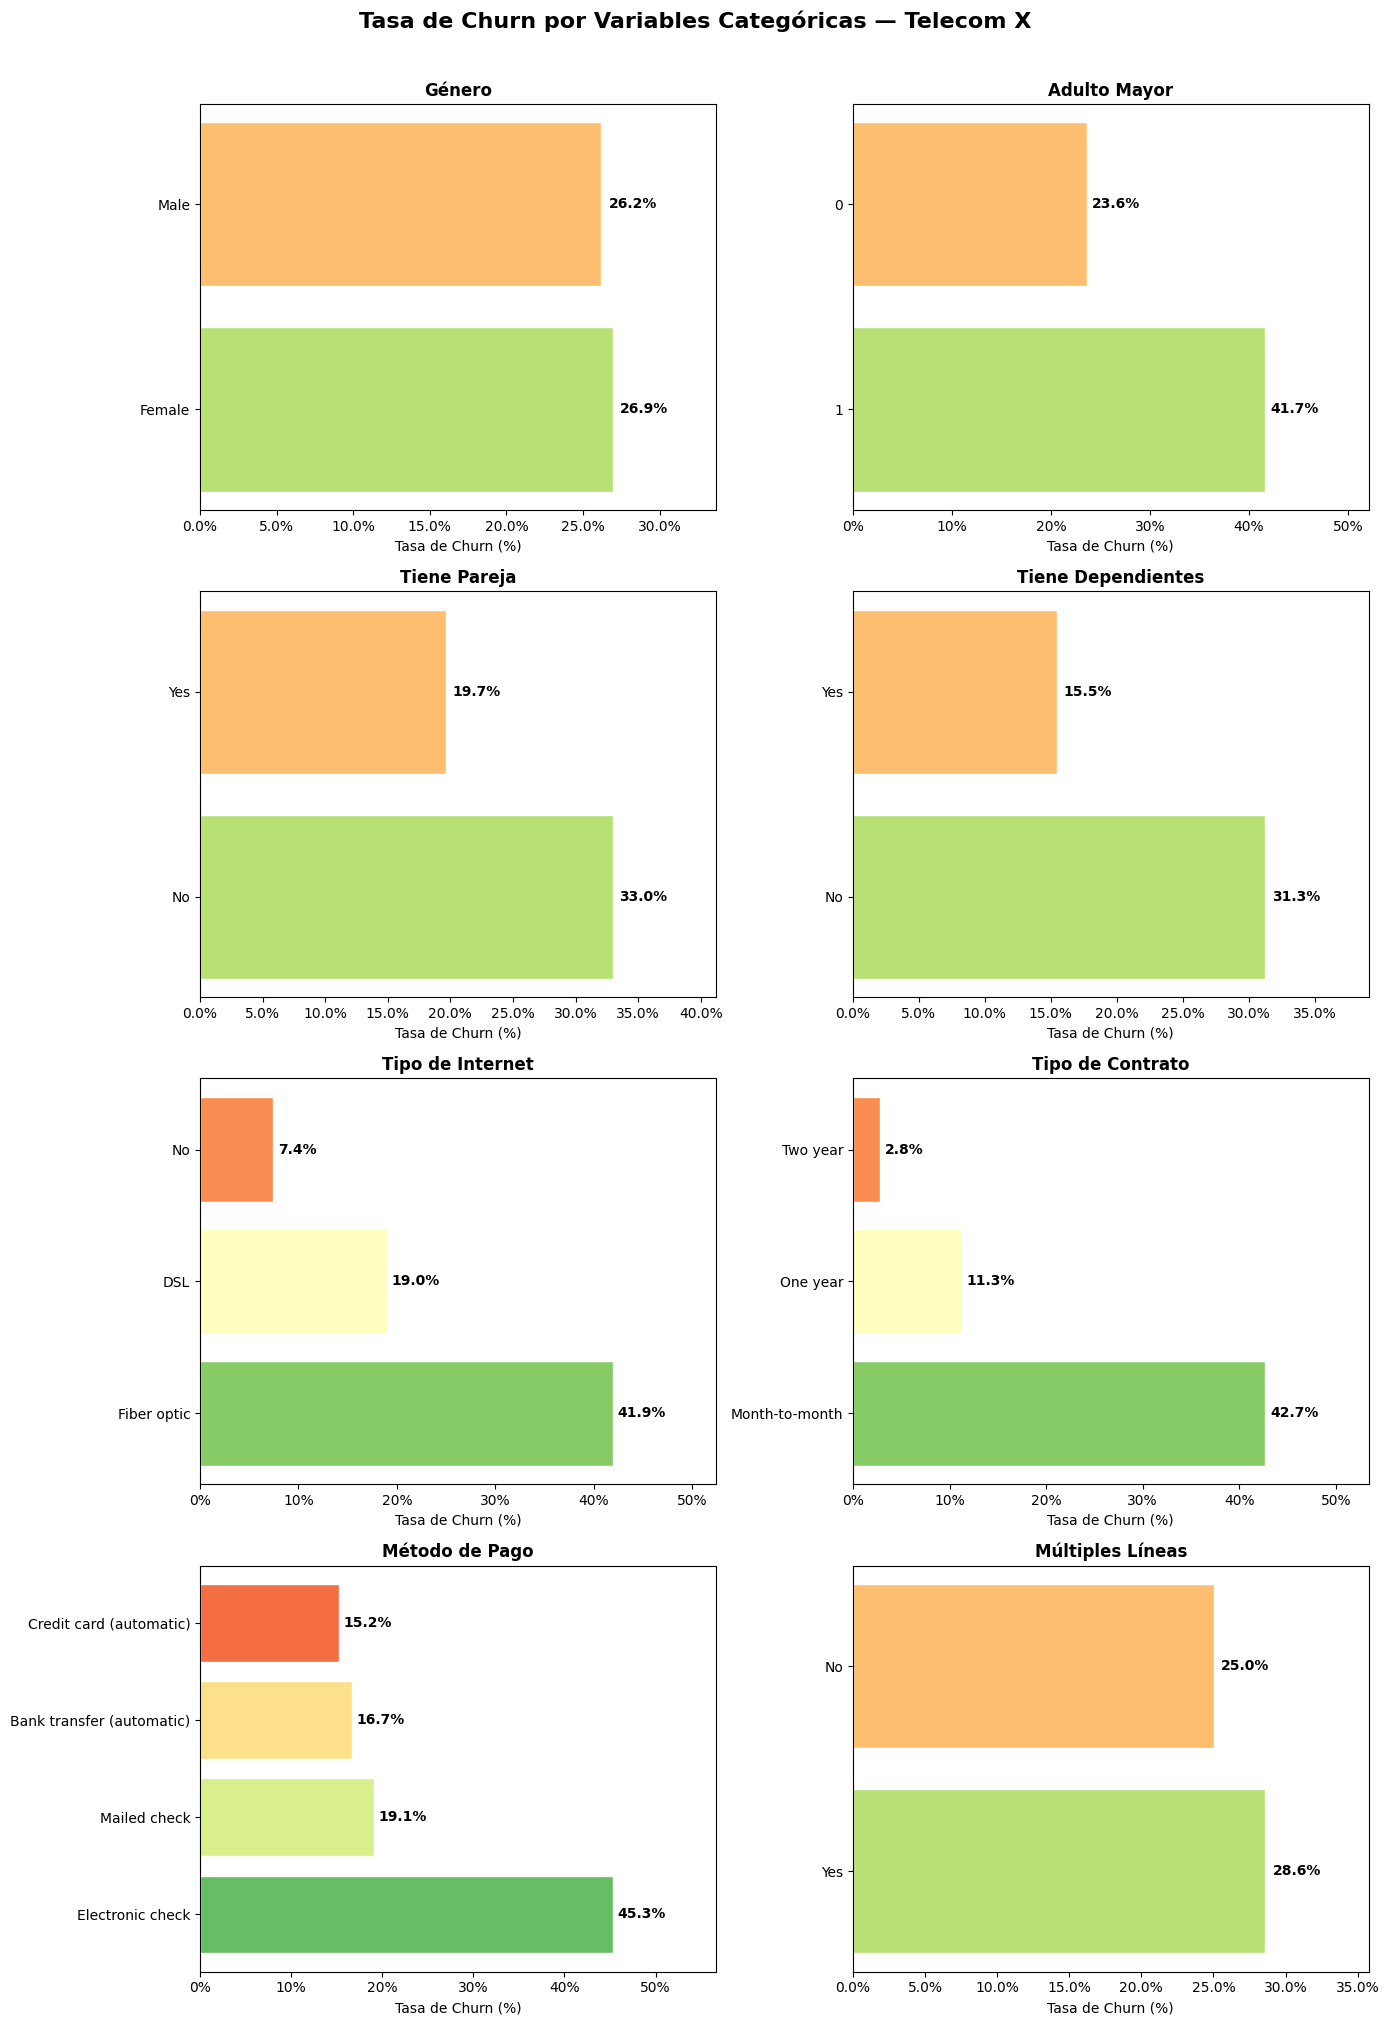

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

def plot_churn_por_categoria(df, col, titulo, ax):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = ax.barh(churn_rate.index.astype(str), churn_rate.values,
                   color=sns.color_palette('RdYlGn_r', len(churn_rate)), edgecolor='white')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Tasa de Churn (%)')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, churn_rate.max() * 1.25)
    for bar in bars:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontweight='bold')

variables = [
    ('customer_gender',          'Género'),
    ('customer_SeniorCitizen',   'Adulto Mayor'),
    ('customer_Partner',         'Tiene Pareja'),
    ('customer_Dependents',      'Tiene Dependientes'),
    ('internet_InternetService', 'Tipo de Internet'),
    ('account_Contract',         'Tipo de Contrato'),
    ('account_PaymentMethod',    'Método de Pago'),
    ('phone_MultipleLines',      'Múltiples Líneas'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('Tasa de Churn por Variables Categóricas — Telecom X',
             fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for ax, (col, titulo) in zip(axes, variables):
    plot_churn_por_categoria(df, col, titulo, ax)

plt.tight_layout()
plt.show()

/tmp/ipykernel_311/88709461.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, 1].set_xticklabels(['Retenidos', 'Evasión'])
/tmp/ipykernel_311/88709461.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, 1].set_xticklabels(['Retenidos', 'Evasión'])
/tmp/ipykernel_311/88709461.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i, 1].set_xticklabels(['Retenidos', 'Evasión'])


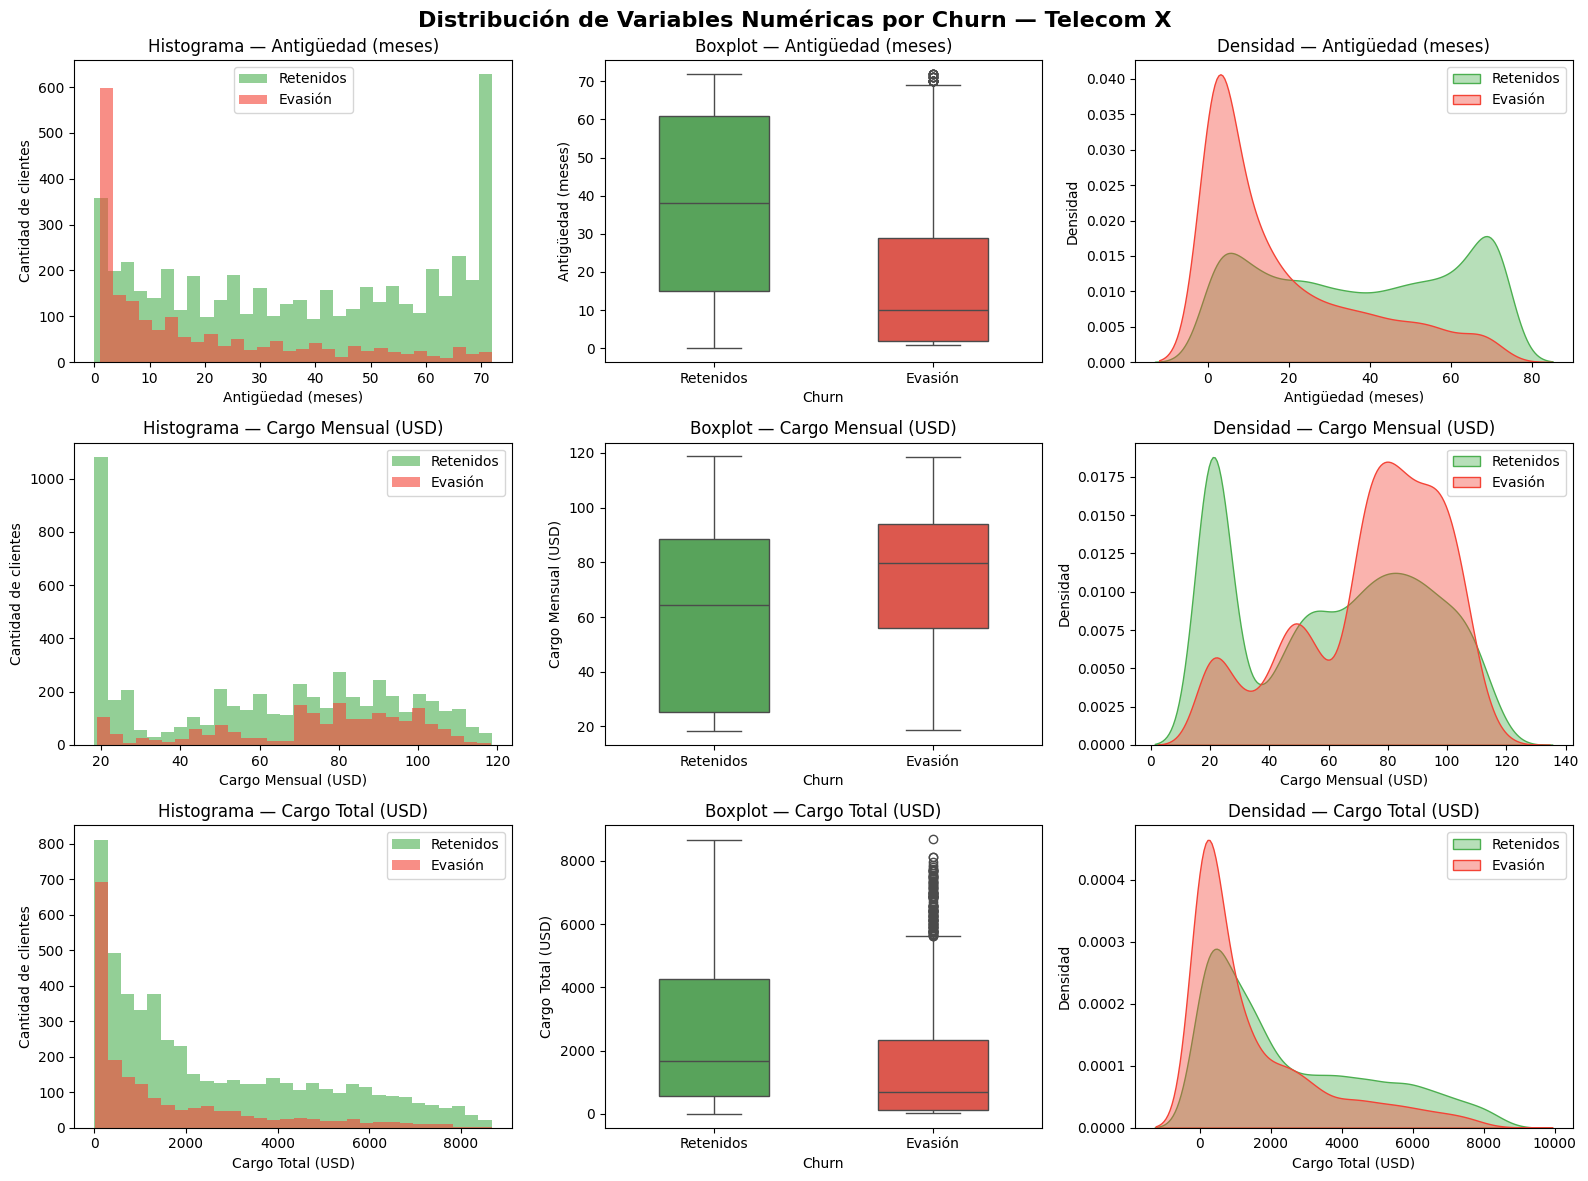

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

numericas = [
    ('customer_tenure',          'Antigüedad (meses)'),
    ('account_Charges_Monthly',  'Cargo Mensual (USD)'),
    ('account_Charges_Total',    'Cargo Total (USD)'),
]

colors = {0: '#4CAF50', 1: '#F44336'}
labels = {0: 'Retenidos', 1: 'Evasión'}

fig, axes = plt.subplots(len(numericas), 3, figsize=(16, 12))
fig.suptitle('Distribución de Variables Numéricas por Churn — Telecom X',
             fontsize=16, fontweight='bold')

for i, (col, titulo) in enumerate(numericas):

    # --- HISTOGRAMA ---
    for churn_val in [0, 1]:
        subset = df[df['Churn'] == churn_val][col]
        axes[i, 0].hist(subset, bins=30, alpha=0.6,
                        color=colors[churn_val], label=labels[churn_val])
    axes[i, 0].set_title(f'Histograma — {titulo}')
    axes[i, 0].set_xlabel(titulo)
    axes[i, 0].set_ylabel('Cantidad de clientes')
    axes[i, 0].legend()

# --- BOXPLOT ---
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i, 1],
                hue='Churn', palette={df['Churn'].unique()[0]: '#4CAF50', df['Churn'].unique()[1]: '#F44336'},
                width=0.5, legend=False)
    axes[i, 1].set_title(f'Boxplot — {titulo}')
    axes[i, 1].set_xlabel('Churn')
    axes[i, 1].set_xticklabels(['Retenidos', 'Evasión'])
    axes[i, 1].set_ylabel(titulo)
    # --- KDE (densidad) ---
    for churn_val in [0, 1]:
        subset = df[df['Churn'] == churn_val][col]
        sns.kdeplot(subset, ax=axes[i, 2], fill=True, alpha=0.4,
                    color=colors[churn_val], label=labels[churn_val])
    axes[i, 2].set_title(f'Densidad — {titulo}')
    axes[i, 2].set_xlabel(titulo)
    axes[i, 2].set_ylabel('Densidad')
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

In [10]:
# ESTADÍSTICAS COMPARATIVAS
print('=== MÉTRICAS COMPARATIVAS: RETENIDOS vs EVASIÓN ===\n')
for col, titulo in numericas:
    print(f'📊 {titulo}')
    stats = df.groupby('Churn')[col].agg(['mean', 'median', 'std']).round(2)
    stats.index = ['Retenidos', 'Evasión']
    stats.columns = ['Media', 'Mediana', 'Desv. Std']
    print(stats)
    print()

=== MÉTRICAS COMPARATIVAS: RETENIDOS vs EVASIÓN ===

📊 Antigüedad (meses)
           Media  Mediana  Desv. Std
Retenidos  37.57     38.0      24.11
Evasión    17.98     10.0      19.53

📊 Cargo Mensual (USD)
           Media  Mediana  Desv. Std
Retenidos  61.27    64.43      31.09
Evasión    74.44    79.65      24.67

📊 Cargo Total (USD)
             Media  Mediana  Desv. Std
Retenidos  2549.91  1679.52    2329.95
Evasión    1531.80   703.55    1890.82



#📄Informe final

# 📡 Telecom X — Informe de Análisis de Evasión de Clientes (Churn)

## 1. Introducción

Telecom X enfrenta una tasa de cancelación de clientes que representa un riesgo
significativo para su rentabilidad. La **evasión de clientes (churn)** ocurre cuando
un cliente decide cancelar el servicio, generando pérdida de ingresos recurrentes y
aumentando los costos de adquisición de nuevos clientes.

**Objetivo del análisis:**
Identificar los factores que impulsan la evasión mediante técnicas de análisis
exploratorio de datos (EDA), con el fin de proporcionar al equipo de Data Science
información accionable para construir modelos predictivos y diseñar estrategias de
retención efectivas.

**Fuente de datos:** API pública de Telecom X — 7.267 registros de clientes con
variables demográficas, de servicio y de cuenta.

## 2. Limpieza y Tratamiento de Datos

Los datos fueron extraídos desde la API en formato JSON con estructura anidada
(sub-objetos: `customer`, `phone`, `internet`, `account`), y normalizados con
`pd.json_normalize()`.

**Problemas identificados y soluciones aplicadas:**

| Problema | Solución |
|---|---|
| `account_Charges_Total` en formato string con espacios vacíos | Conversión a `float` con `pd.to_numeric(errors='coerce')` |
| Valores nulos en `account_Charges_Total` (clientes con tenure=0) | Imputación con `0` |
| `Churn` en formato Yes/No | Conversión a binario: 1 (evasión) / 0 (retención) |
| Categorías inconsistentes: `"No internet service"`, `"No phone service"` | Unificadas como `"No"` |
| Sin filas duplicadas | No requirió tratamiento |

Luego del proceso de limpieza, el dataset quedó con **7.267 filas × 21 columnas**,
sin valores nulos ni duplicados, listo para el análisis exploratorio.

## 3. Análisis Exploratorio de Datos

### 3.1 Distribución general del Churn
Se analizó la proporción de clientes que cancelaron vs. los que permanecieron.
### 3.2 Churn por variables categóricas
Se exploró la tasa de evasión según género, tipo de contrato, método de pago,
tipo de internet, entre otras, para identificar perfiles con mayor riesgo.
### 3.2 Churn por variables categóricas
Se exploró la tasa de evasión según género, tipo de contrato, método de pago,
tipo de internet, entre otras, para identificar perfiles con mayor riesgo.

## 4. Conclusiones e Insights

### 🎯 Tasa de Churn General
El **26.6%** de los clientes canceló el servicio — una tasa elevada que justifica
intervención inmediata.

### 📋 Tipo de Contrato — Factor más crítico
Los contratos **mes a mes** concentran el mayor riesgo de evasión (~42%), mientras
que los contratos a dos años presentan tasas mínimas (~3%). La flexibilidad del
contrato corto reduce el costo de salida para el cliente.

### 🌐 Fiber Optic — Paradoja del servicio premium
A pesar de ser el servicio de mayor valor, los clientes con **Fiber Optic** presentan
la mayor tasa de churn. Esto sugiere una brecha entre las expectativas del cliente
y la experiencia real del servicio (precio, estabilidad o soporte).

### 💳 Método de Pago — Electronic Check
Los clientes que pagan con **cheque electrónico** tienen una tasa de evasión de ~45%.
Los métodos automáticos (débito, tarjeta) están asociados a mayor retención,
posiblemente por el menor esfuerzo de cancelación.

### ⏱️ Antigüedad — Los primeros meses son críticos
La mediana de antigüedad en clientes evadidos es de ~10 meses, frente a ~38 meses
en retenidos. El riesgo de churn es máximo durante el primer año de servicio.

### 💰 Cargos Mensuales — Sensibilidad al precio
Los clientes que cancelan pagan en promedio más por mes que los que permanecen.
Cargos elevados combinados con contratos cortos configuran el perfil de mayor riesgo.

### 👴 Adultos Mayores — Segmento vulnerable
Los **senior citizens** tienen una tasa de churn del ~41%, casi el doble del
resto de los clientes, lo que indica que este segmento requiere atención diferenciada.

### 🔧 Servicios adicionales — Factor protector
Clientes sin `online_security`, `tech_support` ni `online_backup` muestran tasas
de evasión significativamente más altas. La adopción de servicios adicionales
actúa como ancla de retención.

## 5. Recomendaciones Estratégicas

| # | Acción | Segmento objetivo |
|---|---|---|
| 1 | Ofrecer descuentos e incentivos para migrar de contratos mes a mes a contratos anuales | Clientes con contrato mensual |
| 2 | Auditar la calidad y precio del servicio Fiber Optic; evaluar planes de fidelización | Clientes Fiber Optic |
| 3 | Promover activamente el débito automático con beneficios (descuentos, puntos) | Clientes con electronic check |
| 4 | Implementar un programa de onboarding intensivo durante los primeros 12 meses | Clientes nuevos |
| 5 | Diseñar planes y soporte especial para adultos mayores | Senior citizens |
| 6 | Crear bundles que incluyan servicios adicionales (seguridad, soporte) desde el inicio | Todos los segmentos |
| 7 | Desarrollar un modelo predictivo de churn usando las variables identificadas como clave | Equipo de Data Science |

---
*Análisis realizado con Python (Pandas, Matplotlib, Seaborn) — Telecom X, 2024.*